<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

In [2]:
!nvidia-smi

Tue Apr 21 14:56:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Importing dataset

10% of 10-food-classes from Food 101 - https://www.kaggle.com/dansbecker/food-101

https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/04_transfer_learning_in_tensorflow_part_1_feature_extraction.ipynb

In [3]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

--2026-04-21 14:56:23--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.118.207, 74.125.200.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.118.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  16.7MB/s    in 11s     

2026-04-21 14:56:35 (14.3 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



# Glimpse of dataset

In [4]:
import os
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath} ")

There are 2 directories and 0 images in '10_food_classes_10_percent 
There are 10 directories and 0 images in '10_food_classes_10_percent/train 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen 
There are 0 directories and 75 images in '10_food_classes_10_percent/train/stea

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32
EPOCHS = 5

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)
print("Training Images : ")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                          target_size = IMAGE_SHAPE,
                                                          batch_size = BATCH_SIZE,
                                                          class_mode = 'categorical')
print("Testing Images : ")
test_data_10_percent = test_datagen.flow_from_directory(test_dir,
                                                        target_size = IMAGE_SHAPE,
                                                        batch_size = BATCH_SIZE,
                                                        class_mode = 'categorical')

Training Images : 
Found 750 images belonging to 10 classes.
Testing Images : 
Found 2500 images belonging to 10 classes.


# Setting up callbacks

In [6]:
# creating Tensorboard callbacks ( and functionizing it)
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name +"/" + experiment_name +"/"+ datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.Tensorboard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to : {log_dir}")
  return tensorboard_callback

We found the following feature vector model link:
https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/feature-vector/1

In [7]:
rest_net = "https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/feature-vector/1"

In [8]:
IMAGE_SHAPE + (3,)

(224, 224, 3)

In [9]:
def create_model(model_url, num_classes=10):
  """
  takes a tensorflow Hub URL and creates keras sequential model with it.
   Args :
   model_url (str) : A tensorflow hub feature extraction URL.
   num_classes (int) : number of output neurons in the output layers.
   should be equal to the numbre of target classes, default 10

   Returns :
   an uncompiled Keras Sequential Model with model_url as feature extractor layer and Dense output layer with num_classes output features.
   """

  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,
                                           name = "feature_extractor_layer",
                                           input_shape = IMAGE_SHAPE+(3,))

  model = tf.keras.Sequential([
       feature_extractor_layer,
       layers.Dense(num_classes, activation = "softmax", name = "output_layer")
   ])

  return model

### Create RESTNet Tensorflow Hub Feature Extraction Model

In [10]:
restnet_model = create_model(rest_net,
                             num_classes = train_data_10_percent.num_classes)


In [11]:
restnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extractor_layer (K  (None, 2048)              23561152  
 erasLayer)                                                      
                                                                 
 output_layer (Dense)        (None, 10)                20490     
                                                                 
Total params: 23581642 (89.96 MB)
Trainable params: 20490 (80.04 KB)
Non-trainable params: 23561152 (89.88 MB)
_________________________________________________________________


In [12]:
restnet_model.compile(loss="categorical_crossentropy",
                      optimizer = "Adam",
                      metrics=["accuracy"])

### Fitting our RestNet Model to the data

In [13]:
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  # Note the capital 'B' in TensorBoard below
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

In [14]:
restnet_history = restnet_model.fit(train_data_10_percent,
                                    epochs=5,
                                    steps_per_epoch=len(train_data_10_percent),
                                    validation_data=test_data_10_percent,
                                    validation_steps=len(test_data_10_percent),
                                    callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                                           experiment_name="restnet50V1")])

Saving TensorBoard log files to: tensorflow_hub/restnet50V1/20260421-145654
Epoch 1/5
24/24 [==============================] - 23s 562ms/step - loss: 1.9262 - accuracy: 0.3747 - val_loss: 1.0482 - val_accuracy: 0.6668
Epoch 2/5
24/24 [==============================] - 11s 486ms/step - loss: 0.8423 - accuracy: 0.7427 - val_loss: 0.7209 - val_accuracy: 0.7788
Epoch 3/5
24/24 [==============================] - 11s 476ms/step - loss: 0.5592 - accuracy: 0.8507 - val_loss: 0.6334 - val_accuracy: 0.8076
Epoch 4/5
24/24 [==============================] - 12s 502ms/step - loss: 0.4270 - accuracy: 0.9027 - val_loss: 0.5763 - val_accuracy: 0.8216
Epoch 5/5
24/24 [==============================] - 13s 542ms/step - loss: 0.3409 - accuracy: 0.9293 - val_loss: 0.5569 - val_accuracy: 0.8216


In [15]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation matrics.

  Args:
    history : Tensorflow Hisotry object.

  Returns:
    Plots of training/ validation loss and accuracy metrics.
    """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]
  epochs = range(len(history.history["loss"]))

  plt.plot(epochs, loss, label="training Loss")
  plt.plot(epochs, val_loss, label="Val_Loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.figure()
  plt.plot(epochs, accuracy, label="Training Accuracy")
  plt.plot(epochs, val_accuracy, label="Val_Accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

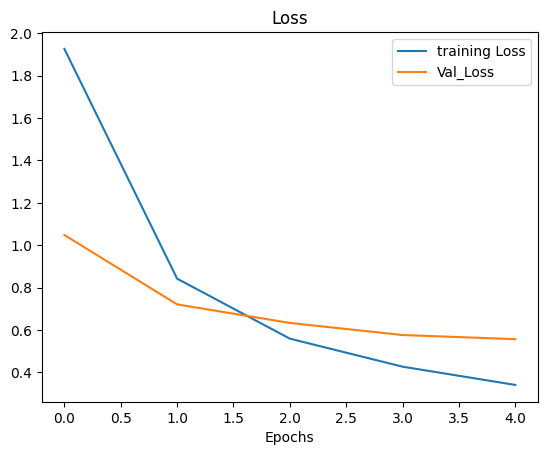

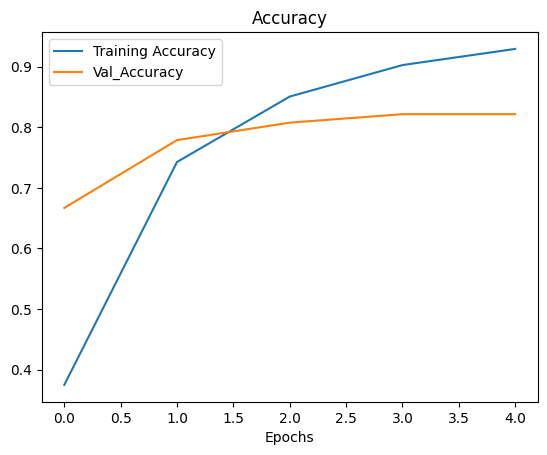

In [16]:
plot_loss_curves(restnet_history)